# Analise Churn de Empregados




### Esse notebook será um passo a passo simples e objetivo de como estimar a probabilidade de um empregado deixar a empresa;

### O dataset utilizado será disponibilizado junto com o arquivo do código;

### O modelo de machine learning utilizado foi o Classificador por Random Forest Classifier


### As bibliotecas utilizadas foram: 
    
#### Pandas:
#### https://pandas.pydata.org/docs/
    
#### Numpy:
#### https://numpy.org/doc/stable/
    
#### Scikit-Learn:
#### https://scikit-learn.org/stable/

#### Matplotlib
#### https://matplotlib.org/



# Analise Exploratória de Dados (EDA)

    

### Random forest is a type of supervised machine learning algorithm based on ensemble learning. Ensemble learning is a type of learning where you join different types of algorithms or same algorithm multiple times to form a more powerful prediction model. The random forest algorithm combines multiple algorithm of the same type i.e. multiple decision trees, resulting in a forest of trees, hence the name "Random Forest". The random forest algorithm can be used for both regression and classification tasks.

### Floresta aleatória é um tipo de algoritmo de aprendizado de máquina supervisionado baseado no aprendizado de conjunto. A aprendizagem por conjunto é um tipo de aprendizagem em que você junta diferentes tipos de algoritmos ou o mesmo algoritmo várias vezes para formar um modelo de previsão mais poderoso. O algoritmo de floresta aleatória combina vários algoritmos do mesmo tipo, ou seja, várias árvores de decisão, resultando em uma floresta de árvores, daí o nome "Floresta aleatória". O algoritmo de floresta aleatório pode ser usado para tarefas de regressão e classificação.

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


### Importa o DataFrame, base de dados.

In [138]:
dataset = pd.read_csv('DataSet.csv')

dataset.head()
#Primeiras 5 linhas do dataframe
#dataset_ = dataset.copy()

,satisfaction,evaluation,number_of_projects,average_montly_hours,time_spend_company,work_accident,churn,promotion,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Qualidade dos Dados

In [3]:
# Informação sobre a base de dados: 

# Tipo dos dados, null values

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
satisfaction            14999 non-null float64
evaluation              14999 non-null float64
number_of_projects      14999 non-null int64
average_montly_hours    14999 non-null int64
time_spend_company      14999 non-null int64
work_accident           14999 non-null int64
churn                   14999 non-null int64
promotion               14999 non-null int64
department              14999 non-null object
salary                  14999 non-null object
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
dataset.describe()

,satisfaction,evaluation,number_of_projects,average_montly_hours,time_spend_company,work_accident,churn,promotion
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [5]:
#Se existir null values posso quantifica-los

dataset.isnull().sum()

satisfaction            0
evaluation              0
number_of_projects      0
average_montly_hours    0
time_spend_company      0
work_accident           0
churn                   0
promotion               0
department              0
salary                  0
dtype: int64

### Características Numéricas

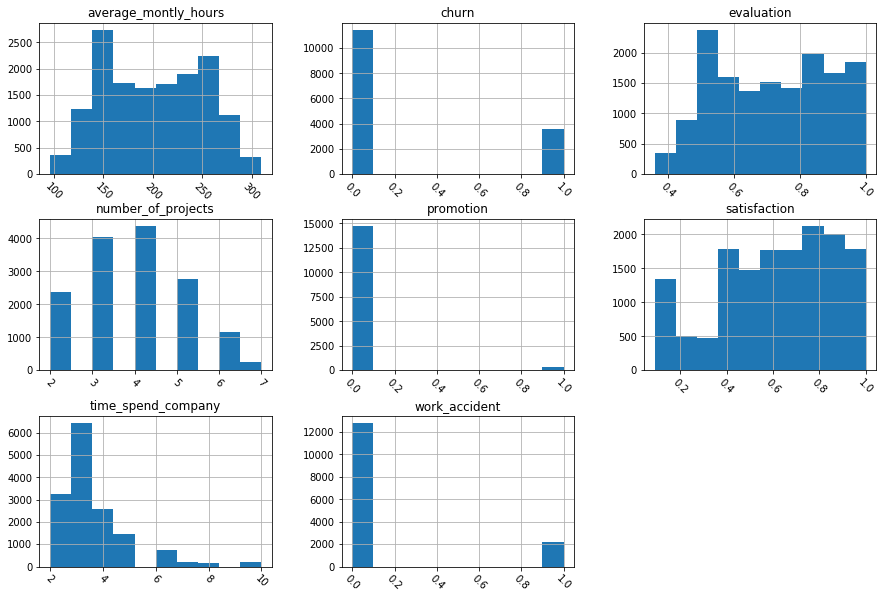

In [6]:
dataset.hist(figsize=(15,10), xrot=-45)
plt.show()

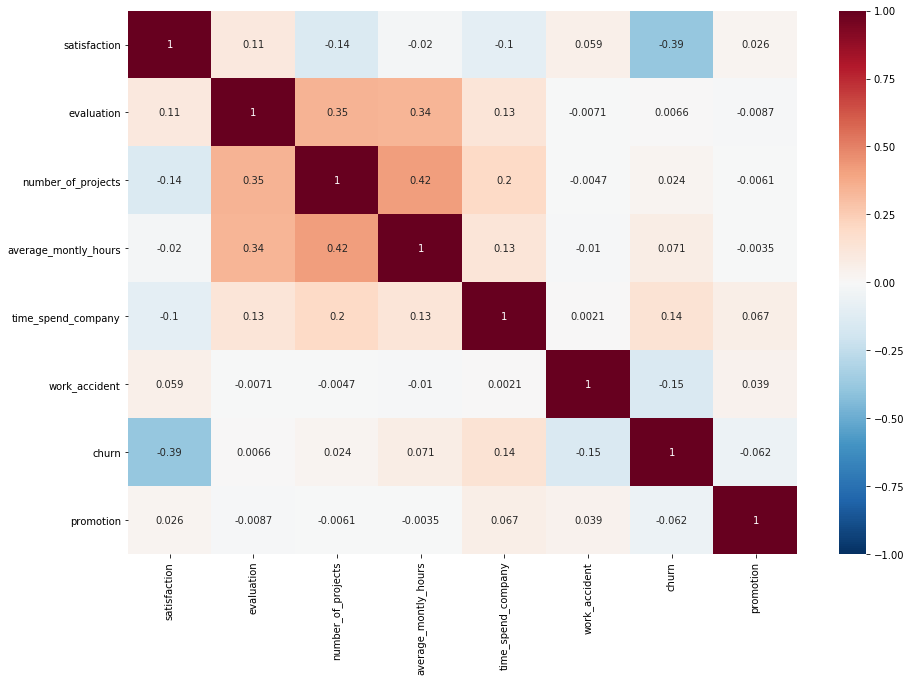

In [7]:
plt.figure(figsize=(15, 10))
sns.heatmap(dataset.corr(), 
    annot=True,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1)
plt.show()

### Características Categoricas

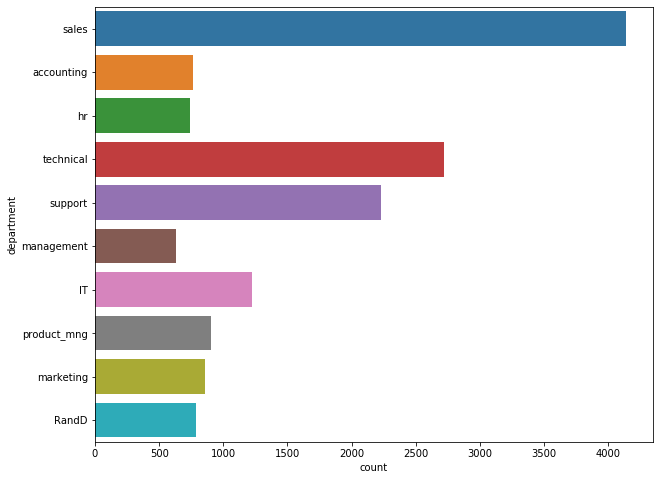

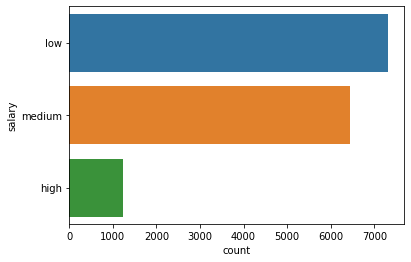

In [8]:
plt.figure(figsize=(10, 8))

for feature in dataset.dtypes[dataset.dtypes=='object'].index:
    
    sns.countplot(data=dataset, y='{}'.format(feature))
    
    plt.show()

### Transformação de valores categoricos

In [9]:
#Valores categoricos

print(dataset['department'].unique(), '\n')
print(dataset['salary'].unique())

['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD'] 

['low' 'medium' 'high']


In [10]:
#Transforma os valores categoricos em numericos
dataset = pd.get_dummies(dataset, columns=['department', 'salary'], drop_first = True)

In [11]:
#Novo DataFrame
dataset.head()

,satisfaction,evaluation,number_of_projects,average_montly_hours,time_spend_company,work_accident,churn,promotion,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


### Segmentação dos dados

#### Extrair insights segmentando caracteristicas numericas contra categoricas

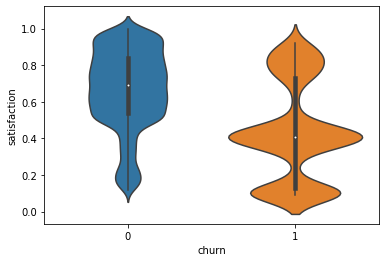

In [12]:
#Índice de Satisfação

sns.violinplot(y='satisfaction', x='churn', data=dataset)

plt.show()

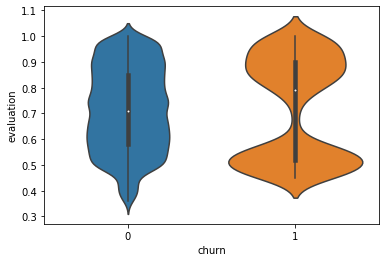

In [13]:
#Índice de avaliação

sns.violinplot(y='evaluation', x='churn', data=dataset)

plt.show()

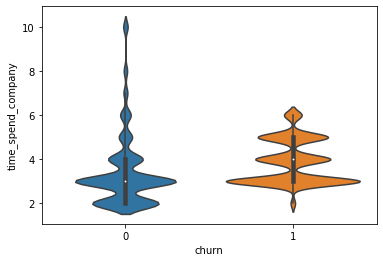

In [14]:
#Tempo de empresa

sns.violinplot(y='time_spend_company', x='churn', data=dataset)

plt.show()

# Feature Engineering

### Clustering para extrair insight através de grupos similares

#### Performance e Satisfação:

<Figure size 1080x1080 with 0 Axes>

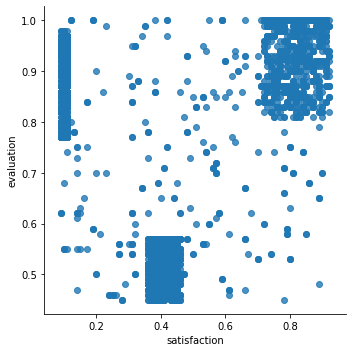

In [15]:
plt.figure(figsize=(15, 15))

sns.lmplot(x='satisfaction',
          y='evaluation',
          data=dataset[dataset.churn==1],
          fit_reg=False
         )

plt.show()

#Baixa performance: evaluation < 0.6
#Desmotivados: satisfaction < 0.2
#Exemplares: evaluation > 0.8 and satisfaction > 0.7


In [16]:
#Categorias

df = dataset.copy()

df['status'] = np.where(
                    df['satisfaction'] < 0.2, 'Desmotivado', 
                        (
                            np.where(
                                df['evaluation'] < 0.6, 'Baixa Perfomance',
                               (
                                   np.where(
                                       (df['evaluation'] > 0.8) & (df['satisfaction'] > 0.7), 'Exemplares',""
                                   )
                                )
                            )
                        )
                    )

df.head()

,satisfaction,evaluation,number_of_projects,average_montly_hours,time_spend_company,work_accident,churn,promotion,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium,status
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0,Baixa Perfomance
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1,Exemplares
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1,Desmotivado
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0,Exemplares
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0,Baixa Perfomance


<Figure size 1080x1080 with 0 Axes>

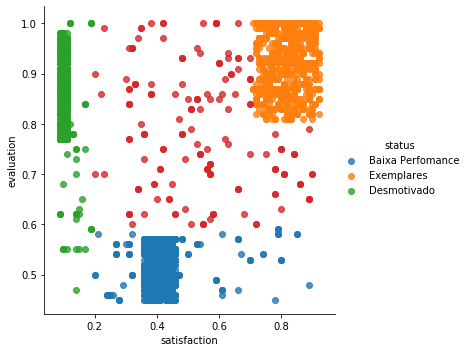

In [17]:
#Clustering por evaluation e satisfaction

plt.figure(figsize=(15, 15))

sns.lmplot(x='satisfaction',
          y='evaluation',
          hue='status',
          data=df[df.churn==1],
          fit_reg=False
         )

plt.show()

In [18]:
# Outra maneira de criar categorias

df['baixa performance'] = (df.evaluation < 0.6).astype(int)
df['desmotivado'] = (df.satisfaction < 0.2).astype(int)
df['exemplar'] = ((df.evaluation > 0.8) & (df.satisfaction > 0.7)).astype(int)


df.head()

,satisfaction,evaluation,number_of_projects,average_montly_hours,time_spend_company,work_accident,churn,promotion,department_RandD,department_accounting,...,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium,status,baixa performance,desmotivado,exemplar
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,1,0,0,1,0,Baixa Perfomance,1,0,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,1,0,0,0,1,Exemplares,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,1,0,0,0,1,Desmotivado,0,1,0
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,1,0,0,1,0,Exemplares,0,0,1
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,1,0,0,1,0,Baixa Perfomance,1,0,0


In [19]:
df[['baixa performance','desmotivado','exemplar']].mean()

baixa performance    0.316154
desmotivado          0.093940
exemplar             0.186212
dtype: float64

##### 31% dos empregados que saíram tinham baixa performance

# Treinamento do Modelo

### Preparar os dados para treino

In [20]:
X = dataset.drop('churn',axis=1)
y = dataset.churn

### Dividir os dados em treino e teste

In [21]:
from sklearn.model_selection import train_test_split


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=df.churn)

### Pipelines para criar passos de processamento

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

#### The purpose of the pipeline is to assemble several steps that can be cross-validated together while setting different parameters.

In [24]:
rf_classifier = RandomForestClassifier(class_weight = "balanced",
                                       random_state=7)

#### Hiperparâmetros 

In [25]:
param_grid = {'n_estimators': [100, 200],
              'max_features': ['auto', 'sqrt', 0.33],
              'min_samples_leaf': [1, 3, 5, 10]}

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
grid_obj = GridSearchCV(rf_classifier,
                        param_grid=param_grid,
                        cv=5)

In [28]:
%%time
grid_fit = grid_obj.fit(X_train, y_train)

Wall time: 3min 47s


In [46]:
#Essa é a performance média atingida pela validação cruzada (CV) dos dados de treino, procedimento 
#de reamostragem usado para avaliar modelos de ML  

RandomForestEstimators = grid_fit.best_estimator_ 

print(grid_obj.best_estimator_)
print(grid_obj.best_params_)
print(grid_obj.best_score_) #Média de performance treino

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight='balanced',
                       criterion='gini', max_depth=None, max_features=0.33,
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=200,
                       n_jobs=None, oob_score=False, random_state=7, verbose=0,
                       warm_start=False)
{'max_features': 0.33, 'min_samples_leaf': 1, 'n_estimators': 200}
0.9890824301792414


### Predições

In [53]:
y_pred = grid_obj.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 1]


In [30]:





# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import confusion_matrix, accuracy_score,
#                             f1_score, roc_curve, roc_auc_score



# from sklearn.preprocessing import StandardScaler


# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)

In [ ]:
O ROC possui dois parâmetros:
Taxa de verdadeiro positivo (True Positive Rate), que é dado por true positives / (true positives + false negatives)
Taxa de falso positivo (False Positive Rate), que é dado por false positives / (false positives + true negatives)

# Avaliação de Performance

In [89]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_curve, roc_auc_score

### Accuracy

In [ ]:
#https://medium.com/@kohlishivam5522/understanding-a-classification-report-for-your-machine-learning-model-88815e2ce397
#https://pt.wikipedia.org/wiki/Precis%C3%A3o_e_revoca%C3%A7%C3%A3o#:~:text=Tanto%20precis%C3%A3o%20quanto%20revoca%C3%A7%C3%A3o%20(ou,compreens%C3%A3o%20da%20medida%20de%20relev%C3%A2ncia.&text=Precis%C3%A3o%20pode%20ser%20traduzida%20como,medida%20de%20completude%20ou%20quantidade.

#### Quantidade de predições corretas / Número Total de predições

#### TP + TN / TP + TN + FP + FN

#### TN / True Negative: O caso foi negativo e o previsto foi negativo
#### TP / True Positive: O caso foi positivo e o previsto foi positivo
#### FN / False Negative: O caso foi positivo mas foi previsto negativo
#### FP / False Positive: O caso foi negativo mas foi previsto positivo

In [60]:
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9936666666666667


### Confusion Matrix

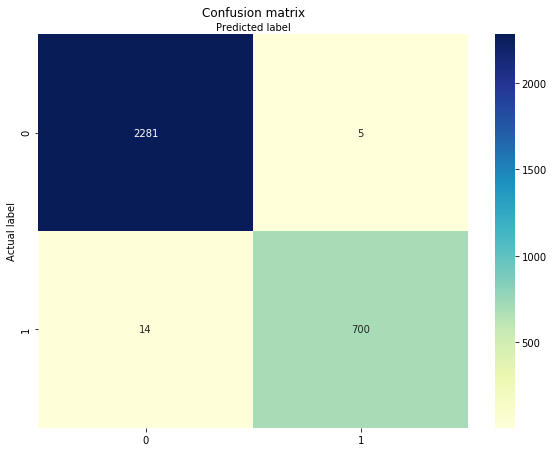

In [82]:
cnf_matrix = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


plt.show()

### Precision
#### Precision é a habilidade de um classificador não classificar positivamente algo que é na verdade é negativo. 
#### Em outras palavras é a acurácia das predições positivas, ou quantos elementos selecionados são relevantes?

In [92]:
#Precision = TP/(TP + FP)

precision = cnf_matrix[1][1]/(cnf_matrix[0][1] + cnf_matrix[1][1])
print(precision)

0.9929078014184397


### Recall
#### Recall é a habilidade do classificador achar todos os positivos.
#### Em outras palavras é a fração de positivos que foram corretamente classificados, ou quantos elementos relevantes foram selecionados?

In [94]:
#Recall = TP/(TP+FN)

recall = cnf_matrix[1][1]/(cnf_matrix[1][0] + cnf_matrix[1][1])
print(recall)

0.9803921568627451


### F1-score
#### F1-score é a média harmônica de precision e recall. Deve ser usada para comparar modelos de classificação e não acurácia global

In [95]:
#F1 Score = 2*(Recall * Precision) / (Recall + Precision)

F1_score = f1_score(y_test, y_pred) 
F1_score

0.9866102889358703

### Support 
#### Support é o número de ocorrências reais de uma determinada classe 

In [91]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2286
           1       0.99      0.98      0.99       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [142]:
#Probabilidades

pred_proba = grid_obj.predict_proba(X_test)


#Probabilidade de sair da empresa (Churn = 1)
pred_proba = pred_proba[:,1] 
pred_proba

array([0.   , 0.375, 0.015, ..., 0.02 , 0.015, 0.995])

### ROC

#### A curva ROC resume todas as matrizes de confusão. 

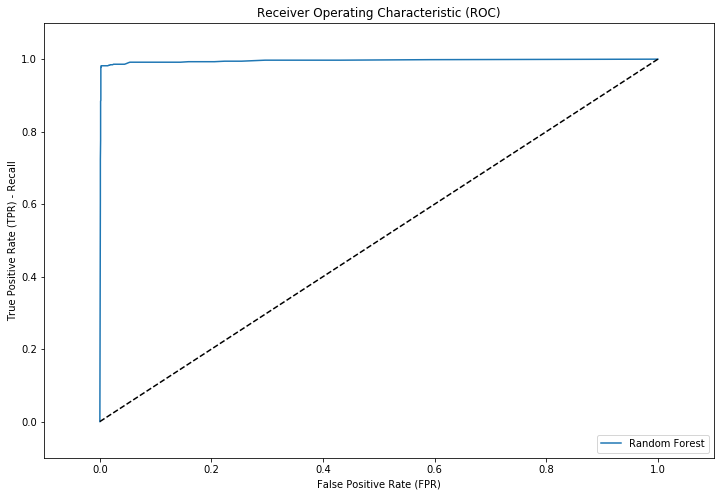

In [139]:
# plot ROC

plt.figure(figsize=(12, 8))

fpr, tpr, thresholds = roc_curve(y_test, pred_proba)

plt.title('Receiver Operating Characteristic (ROC)')
plt.plot(fpr, tpr, label='Random Forest')
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'k--')
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1])
plt.ylabel('True Positive Rate (TPR) - Recall')
plt.xlabel('False Positive Rate (FPR)')
plt.show()


### AUROC

In [133]:
print('AUROC:', roc_auc_score(y_test, y_pred))

AUROC: 0.9891024651330349


In [115]:
#Criar as predições para os valores de todo o dataset

pred_dataset = grid_obj.predict(X)
print(pred_dataset)

[1 1 1 ... 1 1 1]


### Criar a base de dados com os valores de predição

In [128]:
#Criar as probabilidades para os valores de todo o dataset
pred_proba_dataset = grid_obj.predict_proba(X)

#Probabilidade do colaborador deixar a empresa
pred_proba_left = pred_proba_dataset[:,1]

In [132]:
#Criar a base final com o que o modelo estimou
dataset_['predict'] = pred_dataset
dataset_['predict_proba_left'] = pred_proba_left

dataset_.to_csv('Base_churn.csv')